#                                                     CREDIT CARD FRAUD DETECTION 

## 1.Importing all libraries 

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from imblearn.under_sampling import RandomUnderSampler
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix,precision_score,recall_score,f1_score
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import roc_curve, auc
from sklearn.linear_model import LogisticRegression

import sys
!{sys.executable} -m pip install imbalanced-learn


[notice] A new release of pip is available: 25.0.1 -> 25.1
[notice] To update, run: C:\Users\KIIT\AppData\Local\Programs\Python\Python311\python.exe -m pip install --upgrade pip


## 2.Load the dataset and apply EDA

In [32]:
# Load the dataset
df = pd.read_csv('creditcard.csv')
df.head().T

,0,1,2,3,4
Time,0.000000,0.000000,1.000000,1.000000,2.000000
V1,-1.359807,1.191857,-1.358354,-0.966272,-1.158233
V2,-0.072781,0.266151,-1.340163,-0.185226,0.877737
V3,2.536347,0.166480,1.773209,1.792993,1.548718
V4,1.378155,0.448154,0.379780,-0.863291,0.403034
V5,-0.338321,0.060018,-0.503198,-0.010309,-0.407193
V6,0.462388,-0.082361,1.800499,1.247203,0.095921
V7,0.239599,-0.078803,0.791461,0.237609,0.592941
V8,0.098698,0.085102,0.247676,0.377436,-0.270533
V9,0.363787,-0.255425,-1.514654,-1.387024,0.817739


In [3]:
# inforamtion about the dataset
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 non-null  float64
 18  V18     284807 non-null  float64
 19  V19     284807 non-null  float64
 20  V20     284807 non-null  float64
 21  V21     28

In [4]:
#checking the data types of features
df.dtypes

Time      float64
V1        float64
V2        float64
V3        float64
V4        float64
V5        float64
V6        float64
V7        float64
V8        float64
V9        float64
V10       float64
V11       float64
V12       float64
V13       float64
V14       float64
V15       float64
V16       float64
V17       float64
V18       float64
V19       float64
V20       float64
V21       float64
V22       float64
V23       float64
V24       float64
V25       float64
V26       float64
V27       float64
V28       float64
Amount    float64
Class       int64
dtype: object

In [5]:
#statistical analysis of features
df.describe()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
count,284807.000000,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,...,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,284807.000000,284807.000000
mean,94813.859575,1.168375e-15,3.416908e-16,-1.379537e-15,2.074095e-15,9.604066e-16,1.487313e-15,-5.556467e-16,1.213481e-16,-2.406331e-15,...,1.654067e-16,-3.568593e-16,2.578648e-16,4.473266e-15,5.340915e-16,1.683437e-15,-3.660091e-16,-1.227390e-16,88.349619,0.001727
std,47488.145955,1.958696e+00,1.651309e+00,1.516255e+00,1.415869e+00,1.380247e+00,1.332271e+00,1.237094e+00,1.194353e+00,1.098632e+00,...,7.345240e-01,7.257016e-01,6.244603e-01,6.056471e-01,5.212781e-01,4.822270e-01,4.036325e-01,3.300833e-01,250.120109,0.041527
min,0.000000,-5.640751e+01,-7.271573e+01,-4.832559e+01,-5.683171e+00,-1.137433e+02,-2.616051e+01,-4.355724e+01,-7.321672e+01,-1.343407e+01,...,-3.483038e+01,-1.093314e+01,-4.480774e+01,-2.836627e+00,-1.029540e+01,-2.604551e+00,-2.256568e+01,-1.543008e+01,0.000000,0.000000
25%,54201.500000,-9.203734e-01,-5.985499e-01,-8.903648e-01,-8.486401e-01,-6.915971e-01,-7.682956e-01,-5.540759e-01,-2.086297e-01,-6.430976e-01,...,-2.283949e-01,-5.423504e-01,-1.618463e-01,-3.545861e-01,-3.171451e-01,-3.269839e-01,-7.083953e-02,-5.295979e-02,5.600000,0.000000
50%,84692.000000,1.810880e-02,6.548556e-02,1.798463e-01,-1.984653e-02,-5.433583e-02,-2.741871e-01,4.010308e-02,2.235804e-02,-5.142873e-02,...,-2.945017e-02,6.781943e-03,-1.119293e-02,4.097606e-02,1.659350e-02,-5.213911e-02,1.342146e-03,1.124383e-02,22.000000,0.000000
75%,139320.500000,1.315642e+00,8.037239e-01,1.027196e+00,7.433413e-01,6.119264e-01,3.985649e-01,5.704361e-01,3.273459e-01,5.971390e-01,...,1.863772e-01,5.285536e-01,1.476421e-01,4.395266e-01,3.507156e-01,2.409522e-01,9.104512e-02,7.827995e-02,77.165000,0.000000
max,172792.000000,2.454930e+00,2.205773e+01,9.382558e+00,1.687534e+01,3.480167e+01,7.330163e+01,1.205895e+02,2.000721e+01,1.559499e+01,...,2.720284e+01,1.050309e+01,2.252841e+01,4.584549e+00,7.519589e+00,3.517346e+00,3.161220e+01,3.384781e+01,25691.160000,1.000000


In [6]:
# Unique values present in output column
df['Class'].value_counts()

Class
0    284315
1       492
Name: count, dtype: int64

### As we can see that our dataset's labels is imbalanced
### the reason is 284315 are genuine transactions while 492 are considered as fraud
### so our dataset has very less amount of record of fraud transaction comparison to genuine transaction

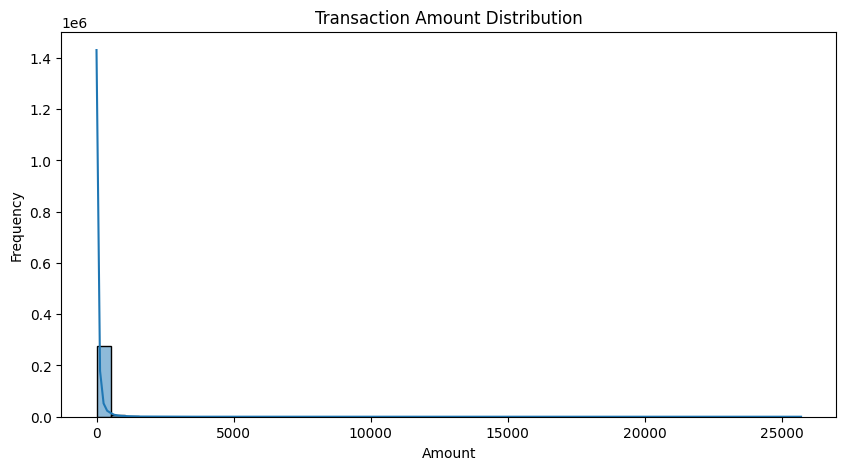

In [8]:
plt.figure(figsize=(10,5))
sns.histplot(df['Amount'], bins=50, kde=True)
plt.title('Transaction Amount Distribution')
plt.xlabel('Amount')
plt.ylabel('Frequency')
plt.show()

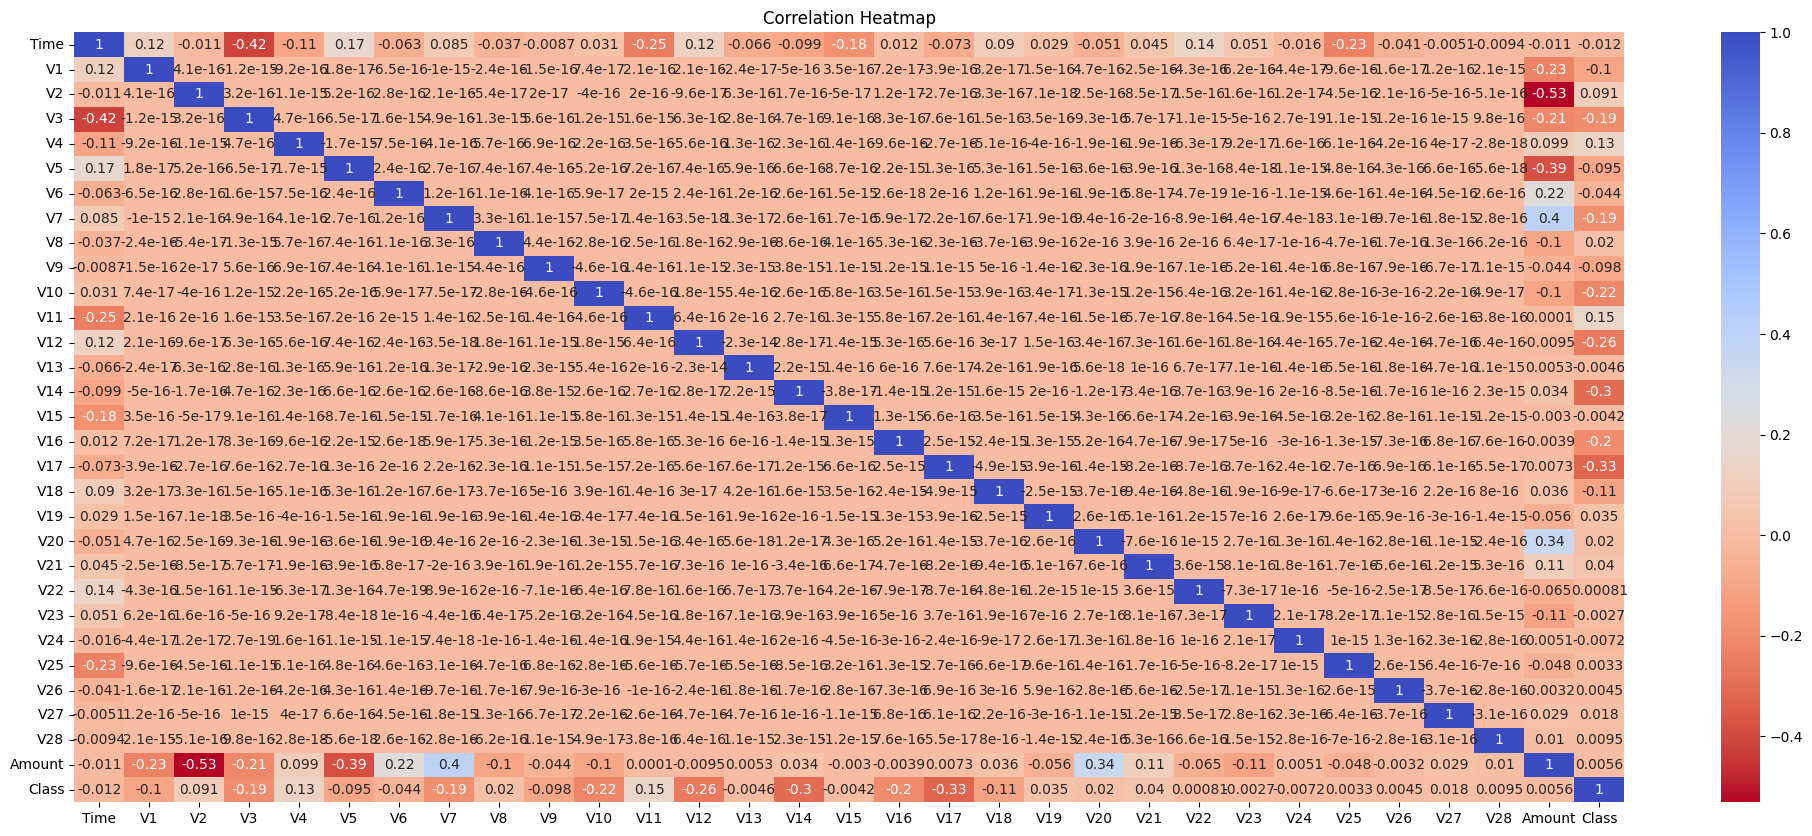

In [9]:
# Correlation heatmap
plt.figure(figsize=(25,10))
sns.heatmap(df.corr(),annot=True,cmap='coolwarm_r')
plt.title('Correlation Heatmap')
plt.show()


In [10]:
# Check for missing values
print(df.isnull().sum())

Time      0
V1        0
V2        0
V3        0
V4        0
V5        0
V6        0
V7        0
V8        0
V9        0
V10       0
V11       0
V12       0
V13       0
V14       0
V15       0
V16       0
V17       0
V18       0
V19       0
V20       0
V21       0
V22       0
V23       0
V24       0
V25       0
V26       0
V27       0
V28       0
Amount    0
Class     0
dtype: int64


In [11]:
# Fill missing values with the mean of the column
df.fillna(df.mean(), inplace=True)

## 3.Standardizing the dataset

In [12]:
# Standardize the column Amount and Time 
scaler = StandardScaler()
df['Amount'] = scaler.fit_transform(df['Amount'].values.reshape(-1,1))
df['Time'] = scaler.fit_transform(df['Time'].values.reshape(-1,1))
df.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,-1.996583,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,0.244964,0
1,-1.996583,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,-0.342475,0
2,-1.996562,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,1.160686,0
3,-1.996562,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,0.140534,0
4,-1.996541,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,-0.073403,0


In [13]:

# Separate features and target
x= df.drop('Class', axis=1)
y = df['Class']



array([[-1.57167813,  0.67557198,  3.09661475, ...,  0.12067813,
         0.37125846,  0.12986764],
       [ 1.0862128 ,  0.28267337,  1.09968968, ...,  0.18010038,
        -0.15603653, -1.37151063],
       [-2.05341145, -1.07763353,  2.75436563, ...,  0.43107071,
        -1.37476078, -0.54645466],
       ...,
       [ 1.99848857, -1.21642389, -3.45029305, ...,  0.74480311,
         0.42174076, -0.89483987],
       [ 0.04075866,  0.60471835, -0.0548408 , ...,  0.4470587 ,
         0.20581325,  1.05275573],
       [-0.55050189, -0.40173308, -0.28085469, ..., -0.29629084,
         0.36070016,  0.32059837]])

## 4.Applying PCA

In [ ]:
# Apply PCA so that we can only consider best 10 principal components
pca = PCA(n_components=10)
x_pca = pca.fit_transform(x)
x_pca

In [14]:
rus = RandomUnderSampler(random_state=42)
x_res, y_res = rus.fit_resample(x_pca, y)

## 5.Splitting the dataset into traiining and testing

In [15]:

# Use 80% for training, 20% for testing
x_train, x_test, y_train, y_test = train_test_split(
    x_res, y_res,
    test_size=0.2,
    random_state=42,
    stratify=y_res
)


## 6.Fitting and trainig data on Random forest model

In [16]:
rf = RandomForestClassifier(random_state=42)
rf.fit(x_train, y_train)

RandomForestClassifier(random_state=42)

<Axes: >

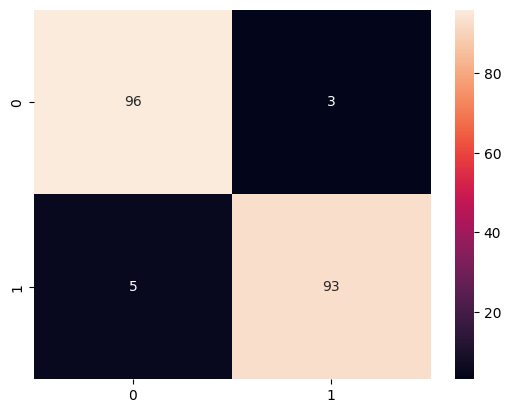

In [17]:
y_pred = rf.predict(x_test)
sns.heatmap(confusion_matrix(y_test,y_pred),annot=True)

In [18]:
rf_precision=precision_score(y_test,y_pred)
rf_precision

0.96875

In [19]:
rf_recall=recall_score(y_test,y_pred)
rf_recall

0.9489795918367347

In [20]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.95      0.97      0.96        99
           1       0.97      0.95      0.96        98

    accuracy                           0.96       197
   macro avg       0.96      0.96      0.96       197
weighted avg       0.96      0.96      0.96       197



## 7.Applying Hyperparamter Tunning on Random Forest to get best paramerter

In [21]:
 #Applying hyperparamter tunnning on Random Forest using Grid Search CV
param_grid = {
   'n_estimators': [100, 200],
    'max_depth': [None, 10, 20],
    'min_samples_split': [2, 5]
}
grid = GridSearchCV(RandomForestClassifier(random_state=42), param_grid, cv=5, scoring='f1')
grid.fit(x_train, y_train)
grid.best_params_

{'max_depth': 10, 'min_samples_split': 2, 'n_estimators': 100}

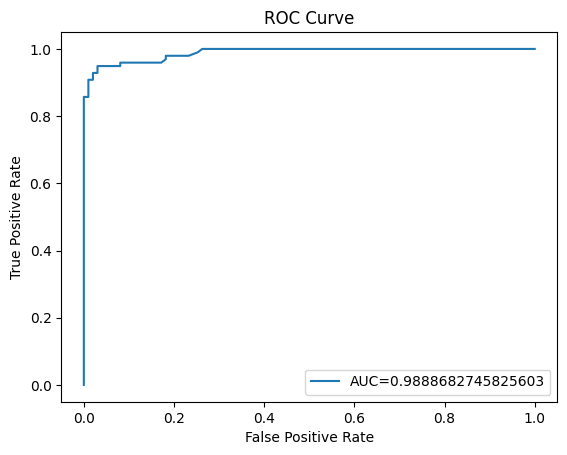

In [23]:
# ROC curve
y_pred_proba = rf.predict_proba(x_test)[::,1]
fpr, tpr, _ = roc_curve(y_test, y_pred_proba)
auc_score = auc(fpr, tpr)

plt.plot(fpr, tpr, label="AUC="+str(auc_score))
plt.legend(loc=4)
plt.title('ROC Curve')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.show()


## 8.Predicting output using Logistic Regression

In [24]:
# Applying Logistic Regression
model=LogisticRegression()
model.fit(x_train,y_train)


LogisticRegression()

In [25]:
y_pred=model.predict(x_test)
lr_precision=precision_score(y_test,y_pred)
lr_precision

0.92

In [26]:
lr_recall=recall_score(y_pred,y_test)
lr_recall

0.92

In [27]:
from sklearn.metrics import accuracy_score
lr_accuracy=accuracy_score(y_pred,y_test)
lr_accuracy

0.9289340101522843

<Axes: >

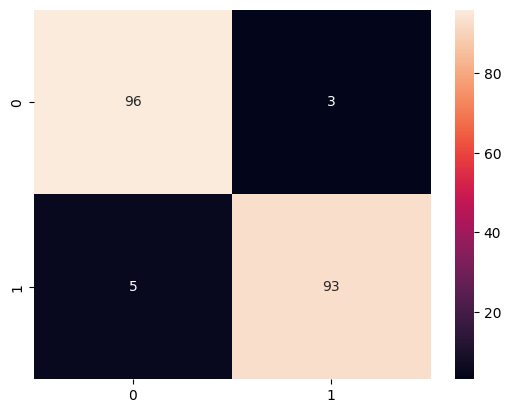

In [28]:
from sklearn.metrics import classification_report, confusion_matrix,precision_score,recall_score,f1_score
y_pred = rf.predict(x_test)
sns.heatmap(confusion_matrix(y_test,y_pred),annot=True)

In [29]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.95      0.97      0.96        99
           1       0.97      0.95      0.96        98

    accuracy                           0.96       197
   macro avg       0.96      0.96      0.96       197
weighted avg       0.96      0.96      0.96       197



## 9.Comparing Model's Performance

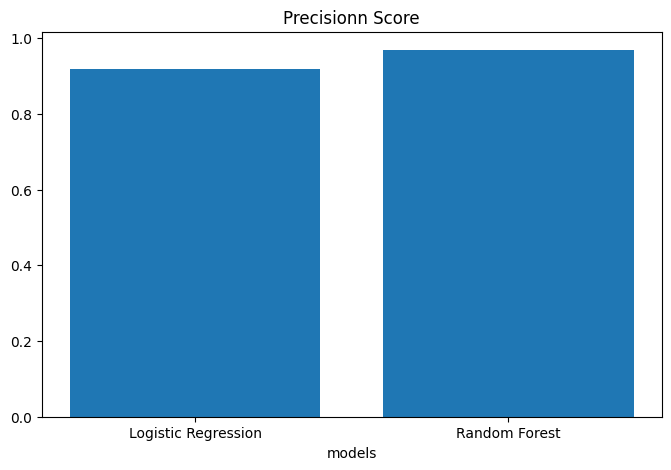

In [30]:
# Precison score for Random Forest and Logistic regression
plt.figure(figsize=(8,5))
plt.bar(["Logistic Regression","Random Forest"],[lr_precision,rf_precision])
plt.title("Precisionn Score")
plt.xlabel("models")
plt.show()

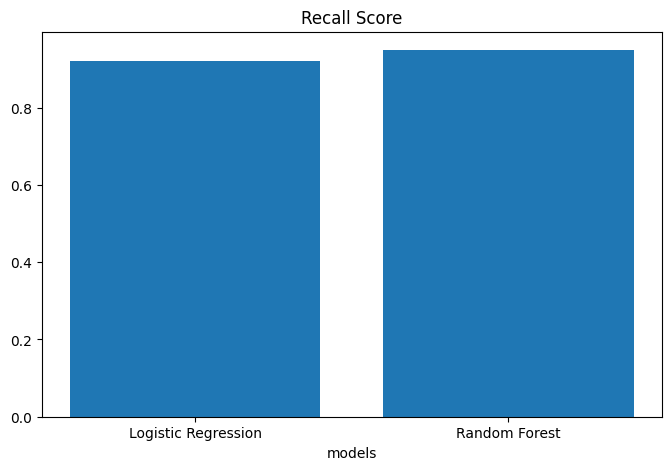

In [31]:
# Recall score for Random Forest and Logistic regression
plt.figure(figsize=(8,5))
plt.bar(["Logistic Regression","Random Forest"],[lr_recall,rf_recall])
plt.title("Recall Score")
plt.xlabel("models")
plt.show()

# Since Precison , Recall and F1 Score of Random Forest Classifier are better than Logistic Regression

# So we will use Random Forest Classifier for predicting that wheather a transaction is fraud or genuine 